In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_excel("social_media_engagement_data.xlsx")

In [5]:
# Understanding Metrics
data['Engagement Rate'] = (data['Likes'] + data['Comments'] + data['Shares']) / data['Reach']

# Data Integrity Assurance
print("Number of records where Impressions outnumber Reach:", sum(data['Impressions'] > data['Reach']))

Number of records where Impressions outnumber Reach: 80107


In [6]:
# Data Enhancement
data['Age Group'] = pd.cut(data['Audience Age'], bins=[0, 30, 45, float('inf')], labels=['Adolescent Adults', 'Mature Adults', 'Senior Adults'])
data['Post Date'] = data['Post Timestamp'].dt.date
data['Post Time'] = data['Post Timestamp'].dt.time

In [7]:
# Temporal Analysis
data['Weekday Type'] = data['Post Timestamp'].dt.day_name()
data['Time Period'] = pd.cut(data['Post Timestamp'].dt.hour, bins=[0, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'])

In [6]:
# Sentiment Analysis
data['Sentiment'].fillna('Mixed Sentiment', inplace=True)

In [7]:
# Geographical Analysis
country_continent_mapping = {
    'Country1': 'Continent1',
    'Country2': 'Continent2',
    # Add more mappings
}
data['Audience Continent'] = data['Audience Location'].map(country_continent_mapping)

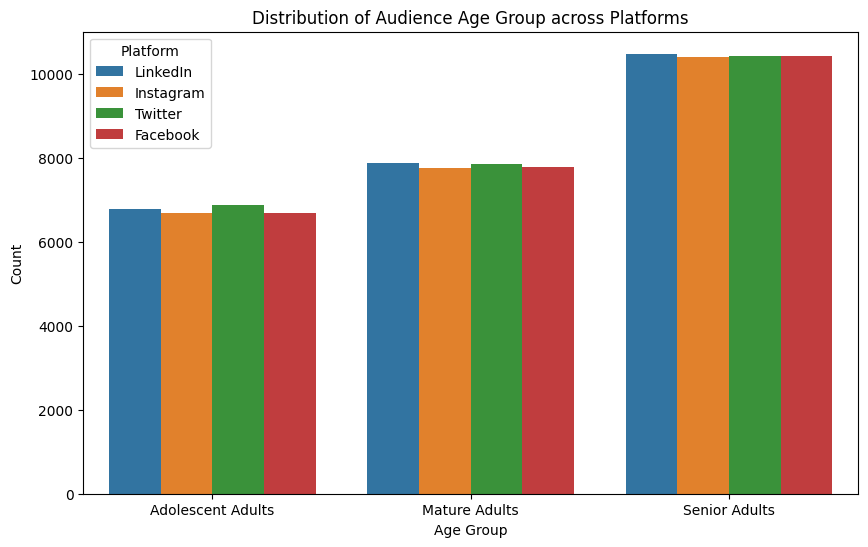

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Age Group', hue='Platform')
plt.title('Distribution of Audience Age Group across Platforms')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

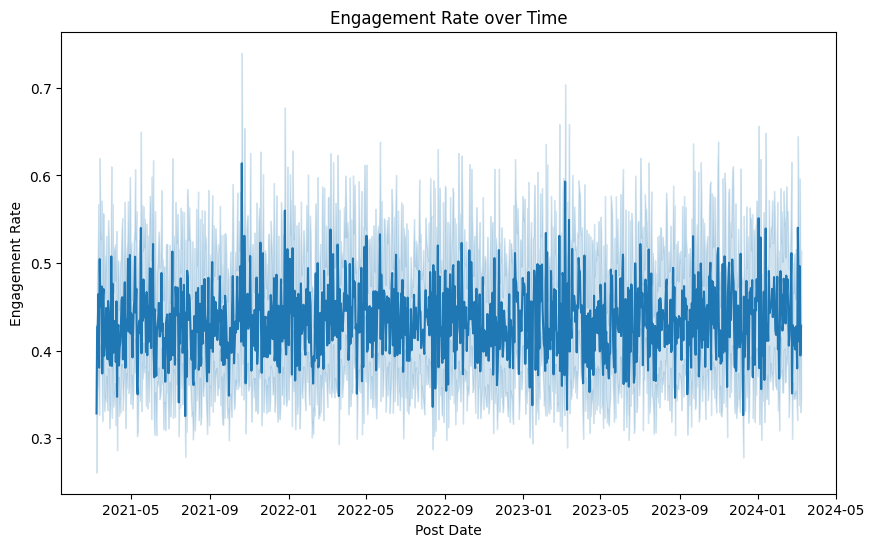

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=data, x='Post Date', y='Engagement Rate')
plt.title('Engagement Rate over Time')
plt.xlabel('Post Date')
plt.ylabel('Engagement Rate')
plt.show()

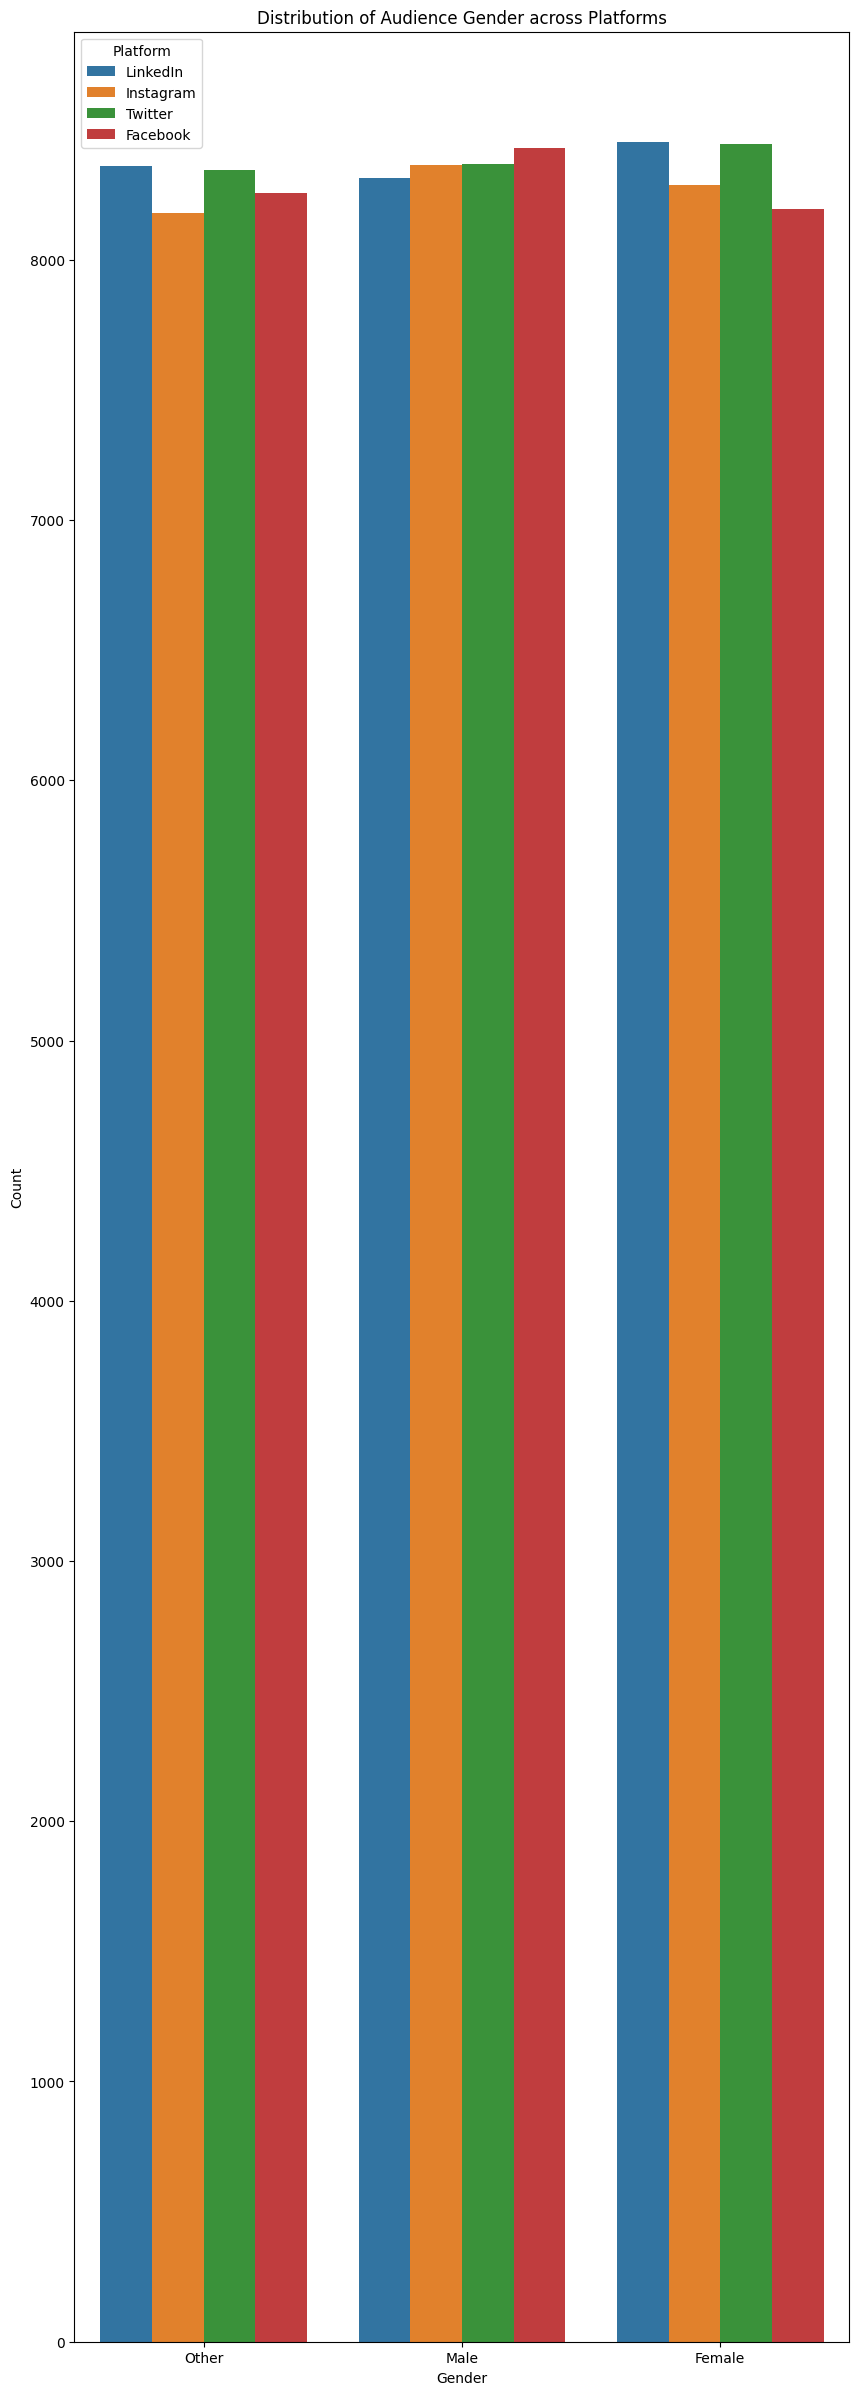

In [14]:
plt.figure(figsize=(10, 30))
sns.countplot(data=data, x='Audience Gender', hue='Platform')
plt.title('Distribution of Audience Gender across Platforms')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

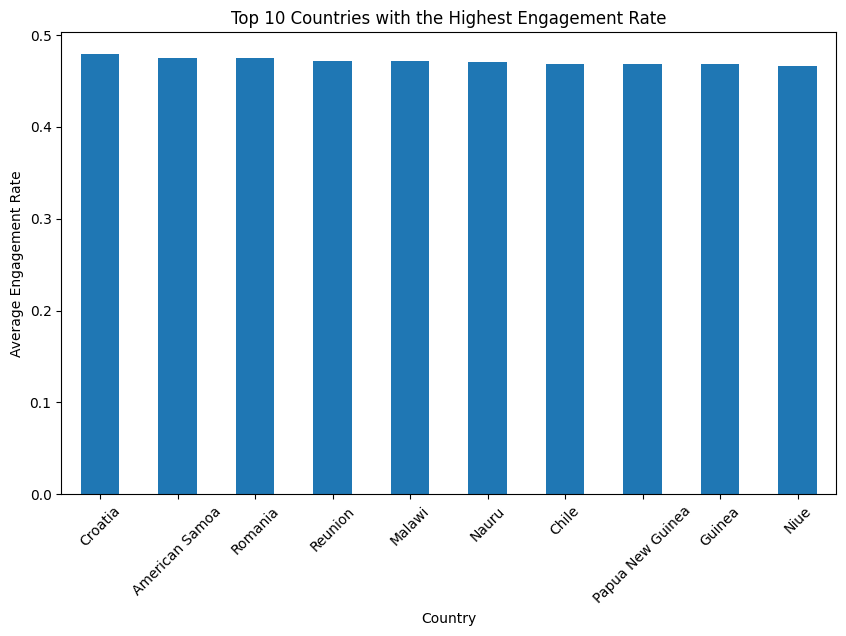

In [15]:
top_countries_engagement = data.groupby('Audience Location')['Engagement Rate'].mean().nlargest(10)
plt.figure(figsize=(10, 6))
top_countries_engagement.plot(kind='bar')
plt.title('Top 10 Countries with the Highest Engagement Rate')
plt.xlabel('Country')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=45)
plt.show()

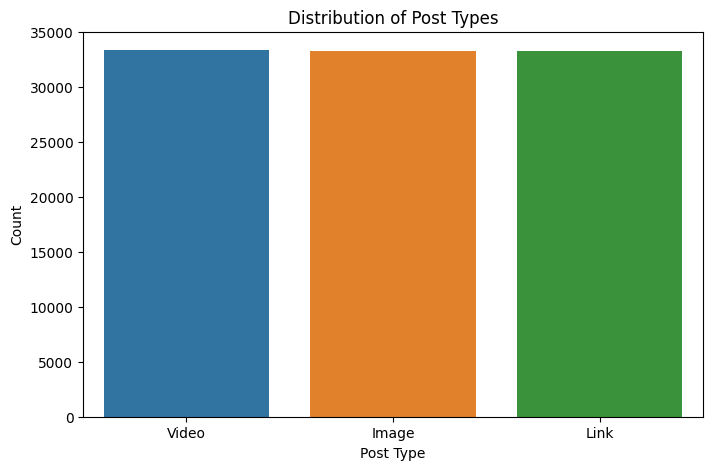

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Post Type')
plt.title('Distribution of Post Types')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

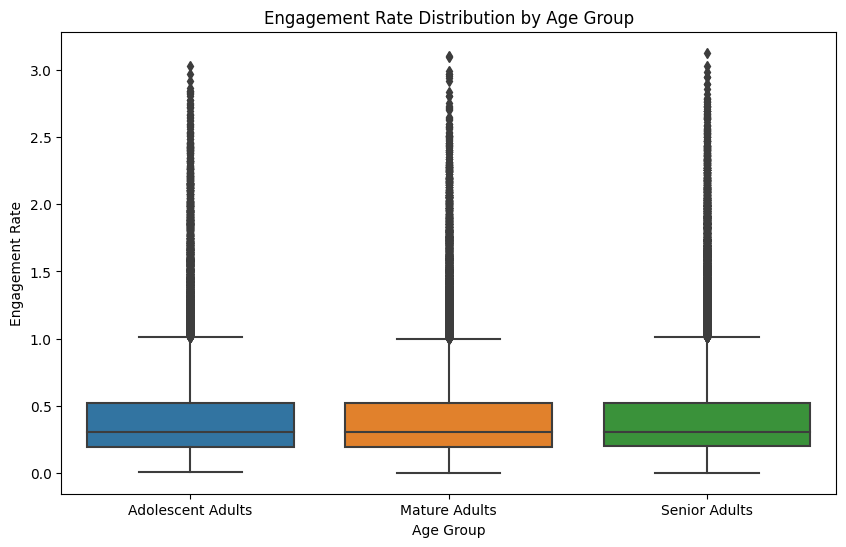

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Age Group', y='Engagement Rate')
plt.title('Engagement Rate Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Engagement Rate')
plt.show()

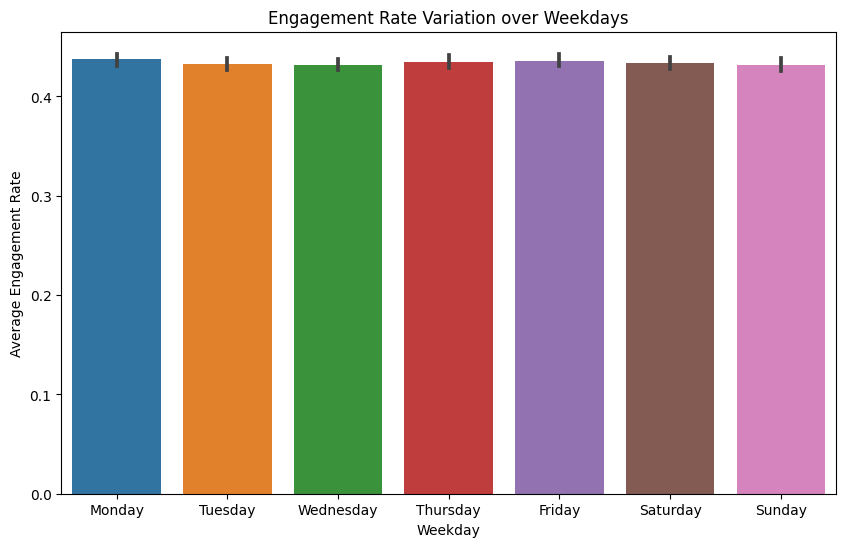

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='Weekday Type', y='Engagement Rate', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Engagement Rate Variation over Weekdays')
plt.xlabel('Weekday')
plt.ylabel('Average Engagement Rate')
plt.show()